In [8]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# 1. API Parameters (Only for features in the image)
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 40.3777,
    "longitude": 49.892,
    "start_date": "2015-01-01",
    "end_date": "2026-04-16",
    "daily": [
        "temperature_2m_mean",          # Index 0 in the image
        "et0_fao_evapotranspiration_sum",# Index 6 in the image
        "sunshine_duration",            # Index 3 in the image
        "shortwave_radiation_sum",      # Index 7 in the image
        "relative_humidity_2m_mean",    # Index 4 in the image
        "surface_pressure_mean",        # Index 9 in the image
        "precipitation_sum",            # Index 1 in the image
        "precipitation_hours",          # Index 2 in the image
        "wind_speed_10m_max",           # Index 8 in the image
        "cloud_cover_mean",             # Index 5 in the image
        "wind_gusts_10m_mean",          # Index 10 in the image
        "soil_moisture_0_to_7cm_mean"   # Our target variable
    ],
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]
daily = response.Daily()

# 2. Reading data from the API (Following the sequence exactly)
daily_data = {
    "date": pd.date_range(
        start=pd.to_datetime(daily.Time(), unit="s", utc=True),
        end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=daily.Interval()),
        inclusive="left"
    ),
    "temperature_2m_mean": daily.Variables(0).ValuesAsNumpy(),
    "et0_fao_evapotranspiration_sum": daily.Variables(1).ValuesAsNumpy(),
    "sunshine_duration": daily.Variables(2).ValuesAsNumpy(),
    "shortwave_radiation_sum": daily.Variables(3).ValuesAsNumpy(),
    "relative_humidity_2m_mean": daily.Variables(4).ValuesAsNumpy(),
    "surface_pressure_mean": daily.Variables(5).ValuesAsNumpy(),
    "precipitation_sum": daily.Variables(6).ValuesAsNumpy(),
    "precipitation_hours": daily.Variables(7).ValuesAsNumpy(),
    "wind_speed_10m_max": daily.Variables(8).ValuesAsNumpy(),
    "cloud_cover_mean": daily.Variables(9).ValuesAsNumpy(),
    "wind_gusts_10m_mean": daily.Variables(10).ValuesAsNumpy(),
    "soil_moisture_0_to_7cm_mean": daily.Variables(11).ValuesAsNumpy()
}

df = pd.DataFrame(data=daily_data)

In [11]:
# 3. Creating Other Calculated Features as shown in the image
# prev_soil_moisture (Yesterday's moisture)
df['prev_soil_moisture'] = df['soil_moisture_0_to_7cm_mean'].shift(1)

# precip_sum_7d (Sum of precipitation over the last 7 days)
df['precip_sum_7d'] = df['precipitation_sum'].rolling(window=7).sum()

# day_of_year (Day of the year)
df['day_of_year'] = df['date'].dt.dayofyear

# The first 7 rows will contain NaN due to 'rolling' and 'shift', so we clean them
df.dropna(inplace=True)

print("\nDataFrame prepared only with the features in the image:\n")
df.head()


DataFrame prepared only with the features in the image:



,date,temperature_2m_mean,et0_fao_evapotranspiration_sum,sunshine_duration,shortwave_radiation_sum,relative_humidity_2m_mean,surface_pressure_mean,precipitation_sum,precipitation_hours,wind_speed_10m_max,cloud_cover_mean,wind_gusts_10m_mean,soil_moisture_0_to_7cm_mean,prev_soil_moisture,precip_sum_7d,day_of_year
18,2015-01-19 00:00:00+00:00,4.753500,1.033541,31512.394531,9.01,83.559387,1028.244751,0.0,0.0,21.986542,29.458334,22.154999,0.173083,0.178333,1.0,19
19,2015-01-20 00:00:00+00:00,6.345167,0.865120,32726.882812,9.47,89.460480,1024.898560,0.0,0.0,25.671307,43.000000,24.750000,0.169542,0.173083,1.0,20
20,2015-01-21 00:00:00+00:00,5.847250,1.055119,33410.996094,9.85,88.103760,1027.502563,0.0,0.0,15.509274,51.458332,13.905002,0.166083,0.169542,1.0,21
21,2015-01-22 00:00:00+00:00,5.701417,0.802787,1402.731934,4.28,86.153473,1027.858276,1.1,7.0,30.602118,92.375000,26.535002,0.169958,0.166083,2.1,22
22,2015-01-23 00:00:00+00:00,4.968083,1.079632,27588.775391,6.32,76.541328,1034.354370,0.0,0.0,23.084955,85.291664,27.690002,0.175958,0.169958,2.1,23


New R2 Score: 0.9726
New MAE: 0.0105


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19772\623739804.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', palette='viridis')


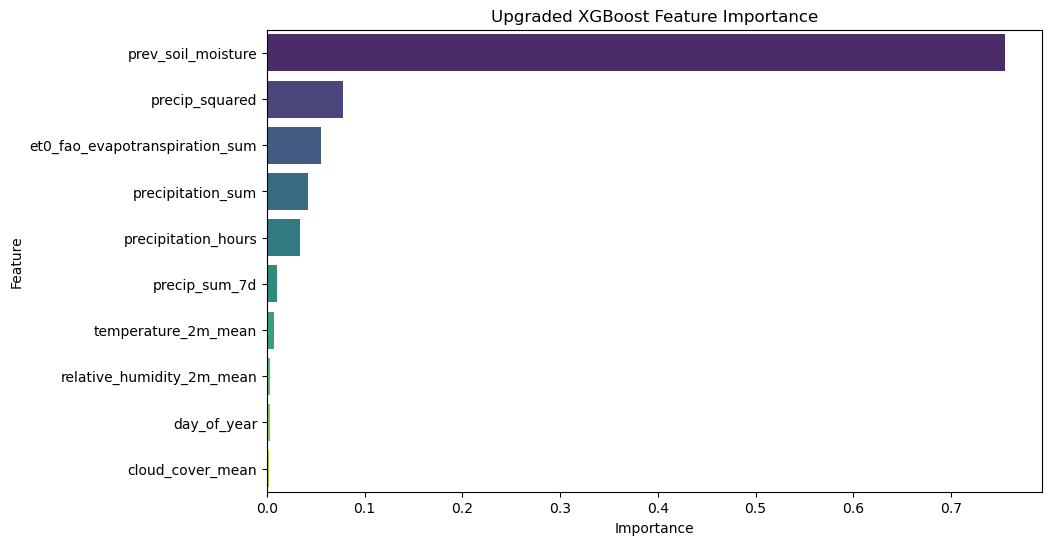

In [13]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Feature Engineering: "Emphasizing" the impact of precipitation
df_upgraded = df.dropna().copy()

# Precipitation squared - makes heavy rainfall more "significant" for the model
df_upgraded['precip_squared'] = df_upgraded['precipitation_sum'] ** 2

# 2. Defining X and y
X_lag = df_upgraded.drop(columns=['date', 'soil_moisture_0_to_7cm_mean'])
y_lag = df_upgraded['soil_moisture_0_to_7cm_mean']

# 3. Time-series split (80/20)
split_idx = int(len(df_upgraded) * 0.8)
X_train_l, X_test_l = X_lag.iloc[:split_idx], X_lag.iloc[split_idx:]
y_train_l, y_test_l = y_lag.iloc[:split_idx], y_lag.iloc[split_idx:]

# 4. Sample Weighting: Increasing the "weight" of rainy days
# Giving 5 times more importance to days with precipitation over 10mm
train_weights = np.where(X_train_l['precipitation_sum'] > 10, 5, 1)

# 5. Tuning the XGBoost Model
xgb_upgraded = xgb.XGBRegressor(
    n_estimators=700, 
    max_depth=5,               
    learning_rate=0.03,        # Slower and more precise learning
    subsample=0.8,
    colsample_bytree=0.9,      # Use 90% of columns (to ensure precipitation isn't missed)
    objective='reg:squarederror',
    random_state=42
)

# Training the model with weights
xgb_upgraded.fit(X_train_l, y_train_l, sample_weight=train_weights)

# 6. Prediction and Metrics
y_pred = xgb_upgraded.predict(X_test_l)

print(f"New R2 Score: {r2_score(y_test_l, y_pred):.4f}")
print(f"New MAE: {mean_absolute_error(y_test_l, y_pred):.4f}")

# 7. Feature Importance Visualization
fi_df = pd.DataFrame({
    'Feature': X_lag.columns, 
    'Importance': xgb_upgraded.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Upgraded XGBoost Feature Importance')
plt.show()

In [14]:
# 1. Get all features the model learned and their medians
all_features_upgraded = X_train_l.columns.tolist()
median_vals_upgraded = X_train_l.median()

def stress_test_upgraded(prev_moisture, temp, precip, et0):
    """
    Stress Test for the Upgraded XGBoost model.
    """
    test_dict = {}
    
    for feature in all_features_upgraded:
        # Adjust specific variables
        if feature == 'prev_soil_moisture' or feature == 'soil_moisture_0_to_7cm_mean_lag1':
            test_dict[feature] = prev_moisture
        elif feature == 'temperature_2m_mean':
            test_dict[feature] = temp
        elif feature == 'precipitation_sum':
            test_dict[feature] = precip
        elif feature == 'precip_squared': # Important column we newly created!
            test_dict[feature] = precip ** 2
        elif feature == 'et0_fao_evapotranspiration_sum':
            test_dict[feature] = et0
        elif feature == 'day_of_year':
            test_dict[feature] = 110 # End of April
        elif feature == 'precip_sum_7d':
            test_dict[feature] = precip 
        else:
            # Fill other columns with medians
            test_dict[feature] = median_vals_upgraded[feature]
            
    # Convert to DataFrame format (Column order must be preserved)
    test_df = pd.DataFrame([test_dict])[all_features_upgraded]
    
    # Prediction with the new model
    prediction = xgb_upgraded.predict(test_df)[0]
    ferq = prediction - prev_moisture
    
    print(f"--- UPGRADED XGBOOST TEST ---")
    print(f"Base Moisture: {prev_moisture:.4f}")
    print(f"Weather Conditions: {precip} mm Rain | {temp}°C Temp")
    print(f"New Model Prediction: {prediction:.4f}")
    print(f"Moisture Change: {ferq:+.4f}") # Shows increase or decrease
    print("-" * 30)

# --- RUN SCENARIOS ---

print("SCENARIO 1: Extreme Rain (60 mm)")
# prev_moisture=0.20, temp=12, precip=60.0, et0=0.5
stress_test_upgraded(0.20, 12, 60.0, 0.5) 

print("\nSCENARIO 2: Extreme Heat and Drought (38°C)")
# prev_moisture=0.20, temp=38, precip=0.0, et0=8.0
stress_test_upgraded(0.20, 38, 0.0, 8.0)

SCENARIO 1: Extreme Rain (60 mm)
--- UPGRADED XGBOOST TEST ---
Base Moisture: 0.2000
Weather Conditions: 60.0 mm Rain | 12°C Temp
New Model Prediction: 0.3140
Moisture Change: +0.1140
------------------------------

SCENARIO 2: Extreme Heat and Drought (38°C)
--- UPGRADED XGBOOST TEST ---
Base Moisture: 0.2000
Weather Conditions: 0.0 mm Rain | 38°C Temp
New Model Prediction: 0.1781
Moisture Change: -0.0219
------------------------------


In [15]:
# 8. Evaluating R2 Score for both Training and Testing sets
from sklearn.metrics import r2_score

# Getting predictions for both sets
y_train_pred = xgb_upgraded.predict(X_train_l)
y_test_pred = xgb_upgraded.predict(X_test_l)

# Calculating R2 scores
r2_train = r2_score(y_train_l, y_train_pred)
r2_test = r2_score(y_test_l, y_test_pred)

print(f"Training R2 Score: {r2_train:.4f}")
print(f"Testing R2 Score: {r2_test:.4f}")

# Optional: Checking for Overfitting
if r2_train > r2_test + 0.1:
    print("Warning: The model might be overfitting (Train R2 is significantly higher than Test R2).")
else:
    print("The model generalization looks consistent.")

Training R2 Score: 0.9984
Testing R2 Score: 0.9726
The model generalization looks consistent.


In [16]:
import joblib

# Saving the model with the name 'BAKU_0_7_xgb.pkl'
joblib.dump(xgb_upgraded, 'BAKU_0_7_xgb.pkl')

print("Model saved successfully!")

Model saved successfully!
